# Session 1 — Corrected student notebook

This notebook provides the complete reconstruction of the e-commerce analysis after the classroom challenge.

The aim is not to produce one unquestionable answer. The aim is to make every transformation, assumption and limitation visible.


## Business question

> Based on the last six months of sales, where should management focus across markets, products and customers? What role do promotions play?

The question contains several undefined concepts. We must define the analytical population, counting unit, sales metric and scope before making recommendations.


## 1. Setup


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Look for the data file in the common package locations.
DATA_CANDIDATES = [
    Path("ecommerce_raw.csv"),
    Path("Data/ecommerce_raw.csv"),
    Path("../Data/ecommerce_raw.csv"),
    Path("../../Data/ecommerce_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "ecommerce_raw.csv was not found. Keep the package folder structure "
        "or place the CSV beside the notebook."
    )

# Keep notebook output compact and readable on screen.
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Data file:", DATA_PATH.resolve())


Data file: /Users/guillaumeleorat/Projects/Teaching/AlbertSchool/Advanced_EDA_DataCollection/Students/Session1/Data/ecommerce_raw.csv


## 2. Import and preserve the raw data

Identifiers are loaded as strings. `df_raw` will not be modified.


In [2]:
# Load identifiers as text because they are labels, not measures.
identifier_types = {
    "order_line_id": "string",
    "order_id": "string",
    "customer_id": "string",
    "product_id": "string",
}

df_raw = pd.read_csv(DATA_PATH, dtype=identifier_types)

print("Shape:", df_raw.shape)
display(df_raw.head(3))
df_raw.info()


Shape: (6000, 16)


,order_line_id,order_id,order_date,customer_id,customer_segment,country,acquisition_channel,product_category,product_id,quantity,unit_price,currency,discount_pct,shipping_cost,returned,payment_status
0,OL-0001783,ORD-001064,2026-05-25,CUS-B-00099,Corporate,Germany,Organic,Electronics,ELE-023,1,531.22,EUR,20,10.17,False,Paid
1,OL-0003918,ORD-002343,2026-06-08,CUS-C-00425,Consumer,Germany,Marketplace,Home,HOM-025,1,128.51,EUR,0,8.49,False,Paid
2,OL-0000222,ORD-000137,2026-04-18,CUS-C-00952,Consumer,Germany,Email,Home,HOM-019,1,65.87,EUR,0,6.83,False,Paid


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_line_id        6000 non-null   string 
 1   order_id             6000 non-null   string 
 2   order_date           6000 non-null   object 
 3   customer_id          5366 non-null   string 
 4   customer_segment     6000 non-null   object 
 5   country              6000 non-null   object 
 6   acquisition_channel  6000 non-null   object 
 7   product_category     6000 non-null   object 
 8   product_id           6000 non-null   string 
 9   quantity             6000 non-null   int64  
 10  unit_price           6000 non-null   float64
 11  currency             6000 non-null   object 
 12  discount_pct         6000 non-null   int64  
 13  shipping_cost        6000 non-null   float64
 14  returned             6000 non-null   bool   
 15  payment_status       6000 non-null   o

## 3. Inspect the physical file

A successful `read_csv()` does not prove that the file was interpreted correctly. We first inspect the first physical lines.


In [3]:
# Read a small text sample without transforming the file.
raw_lines = DATA_PATH.read_text(encoding="utf-8").splitlines()
print("Physical data lines:", len(raw_lines) - 1)
print("Header:", raw_lines[0])
print("First record:", raw_lines[1])


Physical data lines: 6000
Header: order_line_id,order_id,order_date,customer_id,customer_segment,country,acquisition_channel,product_category,product_id,quantity,unit_price,currency,discount_pct,shipping_cost,returned,payment_status
First record: OL-0001783,ORD-001064,2026-05-25,CUS-B-00099,Corporate,Germany,Organic,Electronics,ELE-023,1,531.22,EUR,20,10.17,False,Paid


## 4. Confirm the grain

One row represents an order line. The same order can appear on several rows, and the same customer can place several orders.


In [4]:
# Compare row count with the main business identifiers.
grain_check = pd.Series(
    {
        "Rows": len(df_raw),
        "Order lines": df_raw["order_line_id"].nunique(),
        "Orders": df_raw["order_id"].nunique(),
        "Customers with an ID": df_raw["customer_id"].nunique(),
    },
    name="Count",
)
display(grain_check.to_frame())

# Show that one order can contain several order lines.
lines_per_order = df_raw.groupby("order_id").size()
example_order = lines_per_order[lines_per_order.ge(3)].index[0]
display(df_raw.loc[df_raw["order_id"].eq(example_order)].sort_values("order_line_id"))


,Count
Rows,6000
Order lines,5825
Orders,3486
Customers with an ID,1715


,order_line_id,order_id,order_date,customer_id,customer_segment,country,acquisition_channel,product_category,product_id,quantity,unit_price,currency,discount_pct,shipping_cost,returned,payment_status
5082,OL-0000004,ORD-000003,19/03/2026,<NA>,Consumer,France,Marketplace,Electronics,ELE-016,1,379.43,EUR,0,13.63,False,Paid
5584,OL-0000005,ORD-000003,19/03/2026,<NA>,Consumer,France,Marketplace,Electronics,ELE-028,1,191.89,EUR,10,10.99,False,Paid
5085,OL-0000006,ORD-000003,19/03/2026,<NA>,Consumer,France,Marketplace,Electronics,ELE-014,2,182.79,EUR,15,10.54,False,Paid


### Counting rule

- Count rows with `len(df)`.
- Count orders with `order_id.nunique()`.
- Count identified customers with `customer_id.nunique()`.
- State explicitly that rows with a missing customer identifier cannot contribute to the customer count.


## 5. Parse the dates

**Observation:** the raw column contains `YYYY-MM-DD` and `XX/XX/YYYY` values.

**Evidence:** some first numbers in the slash format exceed 12.

**Business assumption:** all slash-formatted dates follow `DD/MM/YYYY`.

**Treatment:** parse the two formats separately and preserve `order_date_raw`.


In [5]:
# Preserve the original date text before conversion.
df = df_raw.copy()
df["order_date_raw"] = df["order_date"].astype("string")

# Detect the two visual date patterns without interpreting them yet.
date_text = df["order_date_raw"]
iso_pattern = date_text.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
slash_pattern = date_text.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)

date_patterns = pd.Series(
    {
        "YYYY-MM-DD": int(iso_pattern.sum()),
        "XX/XX/YYYY": int(slash_pattern.sum()),
        "Other": int((~iso_pattern & ~slash_pattern).sum()),
    },
    name="Rows",
)
display(date_patterns.to_frame())

# Values whose first slash-separated number exceeds 12 support DD/MM/YYYY.
slash_dates = date_text.loc[slash_pattern]
first_number = slash_dates.str.slice(0, 2).astype(int)
print("Slash dates with first number > 12:", first_number.gt(12).sum())

# Parse each format explicitly, then combine the results.
parsed_dates = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
parsed_dates.loc[iso_pattern] = pd.to_datetime(
    date_text.loc[iso_pattern], format="%Y-%m-%d", errors="coerce"
)
parsed_dates.loc[slash_pattern] = pd.to_datetime(
    date_text.loc[slash_pattern], format="%d/%m/%Y", errors="coerce"
)
df["order_date"] = parsed_dates

print("Unparsed dates:", df["order_date"].isna().sum())
print("Date range:", df["order_date"].min().date(), "to", df["order_date"].max().date())


,Rows
YYYY-MM-DD,4093
XX/XX/YYYY,1907
Other,0


Slash dates with first number > 12: 1151
Unparsed dates: 0
Date range: 2026-01-01 to 2026-06-30


## 6. Structural audit


In [6]:
# Screen missing values and cardinalities before changing the data.
structural_audit = pd.DataFrame(
    {
        "Type": df.dtypes.astype(str),
        "Missing": df.isna().sum(),
        "Cardinality": df.nunique(dropna=False),
    }
)
display(structural_audit)

# Compare exact duplicate rows with repeated line identifiers.
duplicate_check = pd.Series(
    {
        "Exact duplicate copies": int(df.duplicated().sum()),
        "Extra occurrences of order_line_id": int(df["order_line_id"].duplicated().sum()),
        "Rows involved in duplicate pairs": int(df["order_line_id"].duplicated(keep=False).sum()),
    },
    name="Count",
)
display(duplicate_check.to_frame())


,Type,Missing,Cardinality
order_line_id,string,0,5825
order_id,string,0,3486
order_date,datetime64[ns],0,181
customer_id,string,634,1716
customer_segment,object,0,3
country,object,0,5
acquisition_channel,object,0,5
product_category,object,0,11
product_id,string,0,120
quantity,int64,0,32


,Count
Exact duplicate copies,175
Extra occurrences of order_line_id,175
Rows involved in duplicate pairs,350


### Missing customer identifiers

We keep these rows because they still contain valid order, product and market information. We do not invent customer IDs. Customer-level results must refer to **customers with an observed identifier**.


In [7]:
# Quantify the customer information that is missing.
missing_customer_summary = pd.Series(
    {
        "Rows with missing customer_id": df["customer_id"].isna().sum(),
        "Orders containing a missing customer_id": df.loc[df["customer_id"].isna(), "order_id"].nunique(),
        "Customers with an observed ID": df["customer_id"].nunique(),
    },
    name="Count",
)
display(missing_customer_summary.to_frame())


,Count
Rows with missing customer_id,634
Orders containing a missing customer_id,385
Customers with an observed ID,1715


### Exact duplicate records

**Observation:** 175 extra copies repeat complete records and repeat their `order_line_id`.

**Business assumption:** complete repeated records represent duplicated data, not separate sales.

**Treatment:** remove the exact copies once and keep the original raw DataFrame.


In [8]:
# Remove only complete repeated records and keep df_raw unchanged.
rows_before = len(df)
df = df.drop_duplicates().copy()

print("Rows removed:", rows_before - len(df))
print("Rows remaining:", len(df))
print("Repeated order_line_id values remaining:", df["order_line_id"].duplicated().sum())


Rows removed: 175
Rows remaining: 5825
Repeated order_line_id values remaining: 0


## 7. Normalise product-category labels

**Assumptions:** `Electonic` means `Electronics`, and `Home & Living` belongs to `Home`.


In [9]:
# Preserve original labels before standardising them.
df["product_category_raw"] = df["product_category"]

# Normalise spaces and case, then apply two explicit business mappings.
category_clean = df["product_category_raw"].str.strip().str.lower()
category_clean = category_clean.replace(
    {"electonic": "electronics", "home & living": "home"}
)
df["product_category"] = category_clean.str.title()

category_mapping = (
    df[["product_category_raw", "product_category"]]
    .drop_duplicates()
    .sort_values(["product_category", "product_category_raw"])
)
display(category_mapping)
display(df["product_category"].value_counts().to_frame("Rows"))


,product_category_raw,product_category
262,Electonic,Electronics
0,Electronics,Electronics
508,Electronics,Electronics
631,electronics,Electronics
1634,HOME,Home
1,Home,Home
318,Home,Home
1217,Home & Living,Home
3,Office,Office
172,Office,Office


,Rows
product_category,
Office,2151
Home,1905
Electronics,1769


## 8. Interpret quantity values

Negative quantities consistently match the return flag. Their sign carries business meaning. Large positive values require contextual review.


In [10]:
# Preserve quantity before applying any analytical assumption.
df["quantity_raw"] = df["quantity"]

# Inspect negative quantities and the largest positive values.
print("Negative quantity rows:", df["quantity"].lt(0).sum())
print("All negative quantities are marked returned:", df.loc[df["quantity"].lt(0), "returned"].all())

quantity_examples = df.loc[
    df["quantity"].lt(0) | df["quantity"].ge(20),
    ["order_line_id", "customer_segment", "product_category", "quantity", "returned", "payment_status"],
].sort_values("quantity", ascending=False)
display(quantity_examples.head(18))


Negative quantity rows: 232
All negative quantities are marked returned: True


,order_line_id,customer_segment,product_category,quantity,returned,payment_status
1924,OL-0004676,Consumer,Office,999,False,Paid
5224,OL-0001330,Consumer,Office,750,False,Paid
969,OL-0003741,Small Business,Office,500,False,Paid
460,OL-0000280,Small Business,Office,400,False,Paid
1399,OL-0002852,Consumer,Office,300,False,Paid
4038,OL-0004217,Consumer,Office,250,False,Paid
4822,OL-0004548,Corporate,Office,37,False,Paid
5491,OL-0003499,Corporate,Office,34,False,Paid
5246,OL-0002166,Corporate,Office,33,False,Paid
1609,OL-0000076,Corporate,Office,31,False,Paid


### Quantity decision

**Business assumption:** `999` is an unsupported placeholder or entry error. The true quantity is unknown.

We therefore replace only `999` with a missing value. We retain all other large quantities because the dataset does not contain sufficient evidence to reject them.


## 9. Fix the currency assumption


In [11]:
# Assumption: 999 is an unsupported placeholder, so its true value is unknown.
df.loc[df["quantity"].eq(999), "quantity"] = np.nan

# Fixed classroom exchange rates. They are illustrative, not historical daily rates.
FX_TO_EUR = {"EUR": 1.00, "GBP": 1.17, "USD": 0.92}
df["fx_to_eur"] = df["currency"].map(FX_TO_EUR)

print("Quantities changed to missing:", df["quantity"].isna().sum())
print("Rows without an FX assumption:", df["fx_to_eur"].isna().sum())


Quantities changed to missing: 1
Rows without an FX assumption: 0


### Fixed classroom exchange rates

| Currency | EUR value used |
|---|---:|
| EUR | 1.00 |
| GBP | 1.17 |
| USD | 0.92 |

These rates are illustrative assumptions. A production analysis would use an approved source and specify transaction-date, settlement-date or accounting-period conversion.


## 10. Business assumptions used in the corrected analysis

| Issue | Assumption or decision | Consequence |
|---|---|---|
| Exact copies | Remove complete repeated records once | Prevent duplicate sales |
| Dates | Slash dates use `DD/MM/YYYY` | Recover January to June dates |
| Missing customer IDs | Keep the rows, count observed IDs only | Qualify customer conclusions |
| Category labels | Map to Electronics, Home and Office | Recombine fragmented categories |
| Negative quantity | Keep the negative sign | Returns reduce net sales |
| `quantity = 999` | Replace with missing | Exclude one unresolved line |
| Payment status | Exclude `Pending` | Select completed operational sales |
| Currency | Use EUR 1.00, GBP 1.17 and USD 0.92 | Compare markets in EUR |
| Shipping | Exclude shipping cost | Measure sales, not margin |


## 11. Construct operational net sales


In [12]:
# Build merchandise sales after discounts in the transaction currency.
df["gross_line_amount_local"] = df["quantity"] * df["unit_price"]
df["net_line_amount_local"] = (
    df["gross_line_amount_local"] * (1 - df["discount_pct"] / 100)
)

# Convert the line amount to EUR using the fixed classroom rates.
df["net_line_amount_eur"] = df["net_line_amount_local"] * df["fx_to_eur"]

# Exclude Pending lines and the unresolved 999 line from the selected KPI.
# Negative returned quantities remain negative revenue adjustments.
df["analysis_eligible"] = (
    df["quantity"].notna() & df["payment_status"].ne("Pending")
)
df["net_sales_eur"] = df["net_line_amount_eur"].where(
    df["analysis_eligible"], 0.0
)

analysis_df = df.loc[df["analysis_eligible"]].copy()
print("Eligible rows:", len(analysis_df))
print("Operational net sales (EUR):", f"{analysis_df['net_sales_eur'].sum():,.2f}")


Eligible rows: 5577
Operational net sales (EUR): 1,610,617.94


### Reconcile the KPI

Positive sales after discount plus negative return adjustments must equal operational net sales.


In [13]:
# Separate positive sales and return adjustments to reconcile the total.
positive_sales_eur = analysis_df.loc[
    analysis_df["quantity"].gt(0), "net_line_amount_eur"
].sum()
return_adjustment_eur = analysis_df.loc[
    analysis_df["quantity"].lt(0), "net_line_amount_eur"
].sum()
corrected_net_sales_eur = analysis_df["net_sales_eur"].sum()

reconciliation = pd.Series(
    {
        "Positive sales after discount (EUR)": positive_sales_eur,
        "Return adjustment (EUR)": return_adjustment_eur,
        "Operational net sales (EUR)": corrected_net_sales_eur,
    },
    name="Amount",
)
display(reconciliation.to_frame())

assert np.isclose(positive_sales_eur + return_adjustment_eur, corrected_net_sales_eur)


,Amount
Positive sales after discount (EUR),"1,680,120.58"
Return adjustment (EUR),"-69,502.63"
Operational net sales (EUR),"1,610,617.94"


## 12. Recalculate markets, categories and customer segments


In [14]:
# Use one function so each business dimension follows the same definitions.
def business_summary(group_column):
    result = (
        analysis_df.groupby(group_column, dropna=False)
        .agg(
            net_sales_eur=("net_sales_eur", "sum"),
            orders=("order_id", "nunique"),
            customers_with_id=("customer_id", "nunique"),
        )
    )
    result["net_sales_per_order_eur"] = result["net_sales_eur"] / result["orders"]
    return result.sort_values("net_sales_eur", ascending=False)

country_results = business_summary("country")
category_results = business_summary("product_category")
segment_results = business_summary("customer_segment")

print("Markets")
display(country_results.round(2))
print("Product categories")
display(category_results.round(2))
print("Customer segments")
display(segment_results.round(2))


Markets


,net_sales_eur,orders,customers_with_id,net_sales_per_order_eur
country,,,,
France,"476,707.33",985,737,483.97
Germany,"390,645.34",872,658,447.99
Spain,"382,774.09",756,580,506.31
United Kingdom,"261,104.76",569,439,458.88
United States,"99,386.43",222,192,447.69


Product categories


,net_sales_eur,orders,customers_with_id,net_sales_per_order_eur
product_category,,,,
Electronics,"1,039,723.10",1435,961,724.55
Home,"342,402.73",1534,1056,223.21
Office,"228,492.11",1695,1098,134.80


Customer segments


,net_sales_eur,orders,customers_with_id,net_sales_per_order_eur
customer_segment,,,,
Consumer,"884,181.80",1913,1013,462.20
Small Business,"429,212.83",976,467,439.77
Corporate,"297,223.31",515,216,577.13


### Interpretation

- France has the highest operational net sales under the selected assumptions.
- Electronics contributes the most sales, while Office appears in more orders.
- Consumer leads total sales. Corporate leads sales per order.

These findings describe the observed file. They do not measure margin, acquisition cost, market size or long-term customer value.


## 13. Examine the promotion association


In [15]:
# Use positive completed sales lines for the descriptive promotion comparison.
# Returns answer a different question and would distort average transaction value.
promotion_df = df.loc[
    df["analysis_eligible"] & df["quantity"].gt(0)
].copy()
promotion_df["promotion"] = np.where(
    promotion_df["discount_pct"].gt(0), "Discounted", "No discount"
)

promotion_overall = (
    promotion_df.groupby("promotion")
    .agg(lines=("order_line_id", "size"), average_line_eur=("net_line_amount_eur", "mean"))
)

promotion_mix = pd.crosstab(
    promotion_df["product_category"],
    promotion_df["promotion"],
    normalize="index",
).mul(100)

promotion_by_category = (
    promotion_df.groupby(["product_category", "promotion"])["net_line_amount_eur"]
    .mean()
    .unstack()
)

print("Overall average line amount")
display(promotion_overall.round(2))
print("Promotion exposure within each category (%)")
display(promotion_mix.round(1))
print("Average line amount within each category (EUR)")
display(promotion_by_category.round(2))


Overall average line amount


,lines,average_line_eur
promotion,,
Discounted,2220,424.07
No discount,3125,236.38


Promotion exposure within each category (%)


promotion,Discounted,No discount
product_category,,
Electronics,79.20,20.80
Home,43.20,56.80
Office,9.20,90.80


Average line amount within each category (EUR)


promotion,Discounted,No discount
product_category,,
Electronics,613.21,867.85
Home,183.73,227.75
Office,85.93,122.30


### Promotion conclusion

Discounted lines have a higher average amount in the aggregate. Discounts also concentrate in Electronics, which has much higher transaction values. Within every category, discounted lines have a lower average amount.

The aggregate result reflects product mix. The data do not establish that promotions cause higher sales.


## 14. Compare the first answer with the reconstructed result


,Naive mixed units,Corrected EUR,Naive rank,Corrected rank
country,,,,
France,"542,653.02","476,707.33",2,1
Germany,"629,998.40","390,645.34",1,2
Spain,"457,947.13","382,774.09",3,3
United Kingdom,"252,997.59","261,104.76",4,4
United States,"125,324.04","99,386.43",5,5


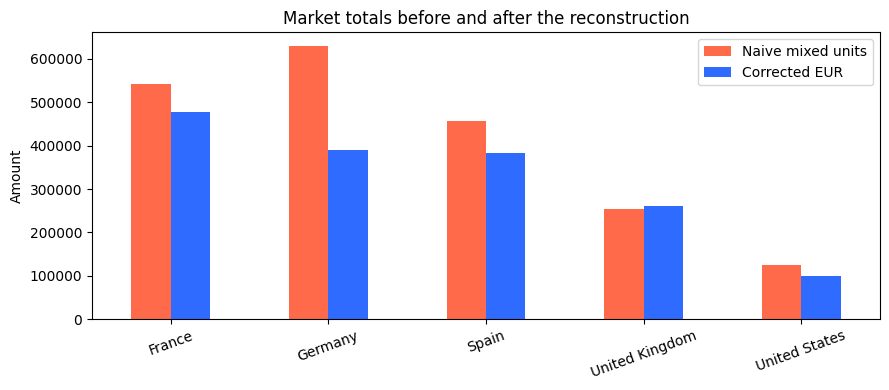

In [16]:
# Reproduce a plausible first answer: raw quantity × price, with no adjustments.
naive_line_value = df_raw["quantity"] * df_raw["unit_price"]
naive_country = naive_line_value.groupby(df_raw["country"]).sum().rename("Naive mixed units")
corrected_country = country_results["net_sales_eur"].rename("Corrected EUR")

country_comparison = pd.concat([naive_country, corrected_country], axis=1)
country_comparison["Naive rank"] = country_comparison["Naive mixed units"].rank(
    ascending=False, method="min"
).astype(int)
country_comparison["Corrected rank"] = country_comparison["Corrected EUR"].rank(
    ascending=False, method="min"
).astype(int)

display(country_comparison.sort_values("Corrected rank").round(2))

ax = country_comparison[["Naive mixed units", "Corrected EUR"]].plot(
    kind="bar",
    figsize=(9, 4),
    color=["#FF6B4A", "#2F6BFF"],
    title="Market totals before and after the reconstruction",
)
ax.set_xlabel("")
ax.set_ylabel("Amount")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 15. Data Quality Decision Log

The log separates evidence from analytical decisions.


In [17]:
decision_log = pd.DataFrame(
    [
        ["Exact duplicates", "175 repeated copies", "Inflated market and category totals", "Remove exact copies", "Copies are not separate events", "No near-duplicate review"],
        ["Mixed dates", "Two patterns; first slash number reaches 31", "Wrong monthly allocation", "Parse formats separately", "Slash format is DD/MM/YYYY", "Source owner has not confirmed"],
        ["Missing customer IDs", "Missing values vary by channel", "Customer profiles may be biased", "Keep and qualify", "No justified imputation", "Unknown customers cannot be deduplicated"],
        ["Quantity 999", "One isolated code-like extreme", "Material effect on Spain and Office", "Set to missing", "Unsupported placeholder", "True quantity unresolved"],
        ["Currencies", "EUR, GBP and USD", "Invalid direct total", "Convert to EUR", "Fixed classroom rates", "No historical rates"],
        ["Promotions", "Aggregate and within-category results differ", "False causal recommendation", "Report association only", "Category mix confounds", "No causal design"],
    ],
    columns=["Issue", "Evidence", "Business impact", "Decision", "Assumption", "Residual risk"],
)
display(decision_log)


,Issue,Evidence,Business impact,Decision,Assumption,Residual risk
0,Exact duplicates,175 repeated copies,Inflated market and category totals,Remove exact copies,Copies are not separate events,No near-duplicate review
1,Mixed dates,Two patterns; first slash number reaches 31,Wrong monthly allocation,Parse formats separately,Slash format is DD/MM/YYYY,Source owner has not confirmed
2,Missing customer IDs,Missing values vary by channel,Customer profiles may be biased,Keep and qualify,No justified imputation,Unknown customers cannot be deduplicated
3,Quantity 999,One isolated code-like extreme,Material effect on Spain and Office,Set to missing,Unsupported placeholder,True quantity unresolved
4,Currencies,"EUR, GBP and USD",Invalid direct total,Convert to EUR,Fixed classroom rates,No historical rates
5,Promotions,Aggregate and within-category results differ,False causal recommendation,Report association only,Category mix confounds,No causal design


## 16. Defensible claims

1. **Market:** France leads operational net sales under the documented assumptions. The United States cannot be compared on the same six-month coverage because its records begin in April.
2. **Customers:** Consumer leads total sales, while Corporate leads sales per order. Missing customer identifiers and absent profitability data limit prioritisation.
3. **Promotions:** product mix explains the positive aggregate association. The dataset cannot identify the causal effect of discounts.

### What cannot yet be trusted

- historical currency conversion;
- US six-month market comparisons;
- complete customer-level counts;
- profitability or acquisition efficiency;
- causal claims about promotions.


## 17. Execution checks


In [18]:
# Final consistency checks. A failed assertion stops the notebook visibly.
assert df_raw.shape == (6000, 16)
assert df_raw.duplicated().sum() == 175
assert len(df) == 5825
assert df["order_line_id"].is_unique
assert df["order_date"].notna().all()
assert df["order_date"].min() == pd.Timestamp("2026-01-01")
assert df["order_date"].max() == pd.Timestamp("2026-06-30")
assert set(df["product_category"].unique()) == {"Electronics", "Home", "Office"}
assert df["quantity"].isna().sum() == 1
assert (df.loc[df["returned"], "quantity"] < 0).all()
assert np.isclose(analysis_df["net_sales_eur"].sum(), 1_610_617.944415)
assert country_results.index[0] == "France"

print("All execution checks passed.")


All execution checks passed.


## Final principle

> **BUSINESS QUESTION → RAW DATA → GRAIN → CHECKS → ASSUMPTIONS → INDICATORS → CLAIM**
